# <center>**brands model lab** 🔬

---

In [1]:
!pip install opencv-python keras tensorflow seaborn tqdm -q


[notice] A new release of pip is available: 23.2.1 -> 24.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
DIR = "/home/tobias/alquimia/models/CV/cars/brands"

### **Set up inference**

In [3]:
# set infer url
model_name = "brands"
rest_url = "http://localhost:8008"
INFER_URL = f"{rest_url}/v2/models/{model_name}/infer"

# set model input shape
INPUT_SHAPE = (1, 75, 75, 3)
TARGET_SIZE = (75, 75)

# set pre-process normalization function
def normalization(img):
    #return (img/127.5)-1. # normalize pixel values from [0, 255] to [-1, 1]
    return img/255. # normalize pixel values from [0, 255] to [0, 1]
    
# set class names
CLASSES = ["AlfaRomeo", "Audi", "Bentley", "Benz", "Bmw"]

# store model parameters for inference in dict
model_config = {
    "infer_url": INFER_URL,
    "target_size": TARGET_SIZE,
    "input_shape": INPUT_SHAPE,
    "pixel_norm": normalization,
    "classes": CLASSES
}

In [4]:
# define function pre-process the image into correct input format
def process_image(image_path, model_condif):
    import tensorflow as tf
    from tensorflow.keras.preprocessing import image
    import numpy as np

    # load and resize image
    size = model_config["target_size"]
    img = image.load_img(image_path, target_size=size)
    # convert the image to an array
    img_array = image.img_to_array(img)
    # normalize the image
    normalization = model_config["pixel_norm"]
    img_array = normalization(img_array)
    # convert to TensorFlow tensor
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
    # add batch dimension
    img_tensor = tf.expand_dims(img_tensor, axis=0)
    
    return img_tensor.numpy().tolist()

In [5]:
# define function to call deployed model from inference url
def classify_img(img_path, model_config):
    import requests
    import json

    # load and process image
    image_list = process_image(img_path, model_config)

    # set payload 
    shape = model_config["input_shape"]
    payload = {
        "inputs": [
            {
                "name": "keras_tensor",
                "shape": shape,
                "datatype": "FP32",
                "data": image_list
            }
        ]
    }

    # send the request
    response = requests.post(INFER_URL, json=payload)
    
    # check the response and return the output
    if response.status_code == 200:
        response_json = response.json()
        probs = response_json["outputs"][0]["data"]
        max_index = probs.index(max(probs))
        pred_class = model_config["classes"][max_index]        
        return {"pred": pred_class, "probs": probs}
    else:
        error_msg = f"Status code:{response.status_code}"+f"\nResponse:{response.text}"
        print(error_msg)

### **Make predictions**

2024-07-16 16:51:10.031483: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-16 16:51:10.045890: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-16 16:51:10.063285: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-16 16:51:10.068471: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-16 16:51:10.080587: I tensorflow/core/platform/cpu_feature_guar

{'pred': 'Bentley', 'probs': [0.07832861, 0.029462062, 0.7377718, 0.1542052, 0.00023229004]}


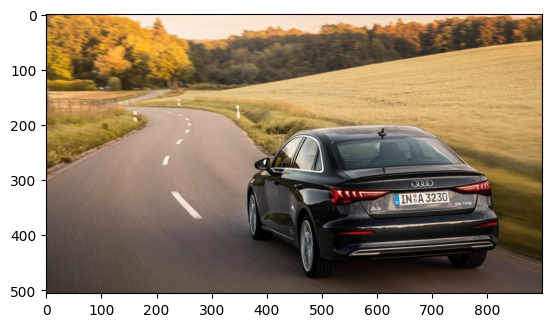

In [6]:
import matplotlib.pyplot as plt
import os

### prediction sample 
file_name = "Audi/audi-a3-2023-1590891.jpg"
folder = "data/sample/"
image_path = os.path.join(DIR, folder+file_name)

sample = classify_img(image_path, model_config)
print(sample)

img = plt.imread(image_path)
plt.imshow(img);

In [7]:
# make predictions with the validation set
from tqdm import notebook
import pandas as pd

validation_set = pd.read_csv(DIR+"/data/validation_set.csv").iloc[:,1].tolist()

classes = model_config["classes"]
true_class = []
predicted_class = []

# traverse through each class folder
for image_name in notebook.tqdm(validation_set, leave=True):
    if image_name.endswith(('jpg', 'jpeg')): #'png'
        # get image path
        image_path = os.path.join(DIR, "data/train_set/", image_name)
        # save true class
        true_class.append(image_name.split("/")[0])
        # make pred and save it
        model_output = classify_img(image_path, model_config)
        pred = model_output["pred"]
        probs = model_output["probs"]
        predicted_class.append(pred)

  0%|          | 0/282 [00:00<?, ?it/s]

### **Error analysis**

In [8]:
# create classification report
from sklearn.metrics import classification_report

report = classification_report(true_class, predicted_class)
print(report)

              precision    recall  f1-score   support

   AlfaRomeo       0.90      0.89      0.90        73
        Audi       0.77      0.83      0.80        53
     Bentley       0.87      0.91      0.89        68
        Benz       0.83      0.81      0.82        42
         Bmw       0.85      0.76      0.80        46

    accuracy                           0.85       282
   macro avg       0.85      0.84      0.84       282
weighted avg       0.85      0.85      0.85       282



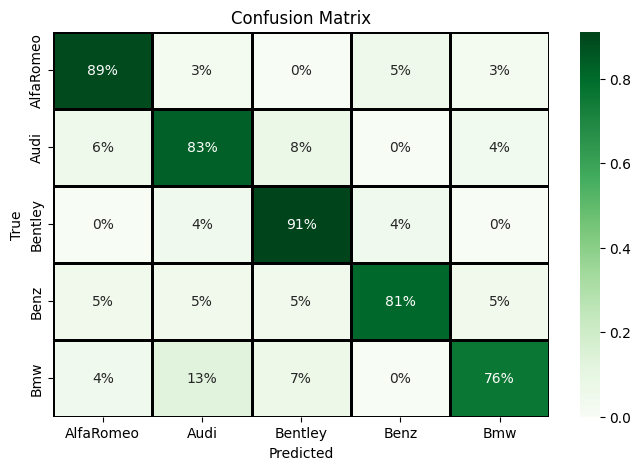

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import numpy as np

# generate confusion matrix
cm = confusion_matrix(true_class, predicted_class)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

cm_normalized_df = pd.DataFrame(cm_normalized, index=classes, columns=classes)

# plot confusion matrix
plt.figure(figsize=(8,5))
sns.heatmap(cm_normalized_df, fmt='.0%', annot=True, linewidth=1, cmap="Greens", linecolor='black')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True');

---